In [1]:
# Data handling
import pandas as pd
import numpy as np

# Text processing
import re
import nltk

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Save model
import pickle

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

In [3]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\Windows 11-Pro
[nltk_data]     Edu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Windows 11-Pro
[nltk_data]     Edu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Windows 11-Pro
[nltk_data]     Edu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Windows 11-Pro
[nltk_data]     Edu\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
df = pd.read_csv("BanglaExtremistDataset.csv")
df.head()

,comments,extremist
0,"সমাবেশ করতে দেওয়াই উচিত না, গ্রেনেড মারা দলকে",1
1,"সমাবেশ নয়াপল্টনেই হবে,,পুলিশ বাধা দিলে পুলিশকে...",1
2,"আমি আমার ভোট দিব, এ অধিকার ফিরে পেতে চাই",0
3,মুক্তিকামী মানুষের জয় হবে ইনশাআল্লাহ,0
4,রাজনীতি এবং রাজনীতিবিদ বর্তমানে দেশের মানুষের ...,1


In [6]:
df["extremist"].value_counts().sum()

np.int64(1989)

In [7]:
df.columns

Index(['comments', 'extremist'], dtype='object')

In [8]:
df["extremist"].value_counts()

extremist
0    1101
1     888
Name: count, dtype: int64

In [12]:
print("Class distribution:")
print(df["extremist"].value_counts())
print()
print("Class balance (%):")
print(df["extremist"].value_counts(normalize=True).mul(100).round(1))

Class distribution:
extremist
0    1101
1     888
Name: count, dtype: int64

Class balance (%):
extremist
0    55.4
1    44.6
Name: proportion, dtype: float64


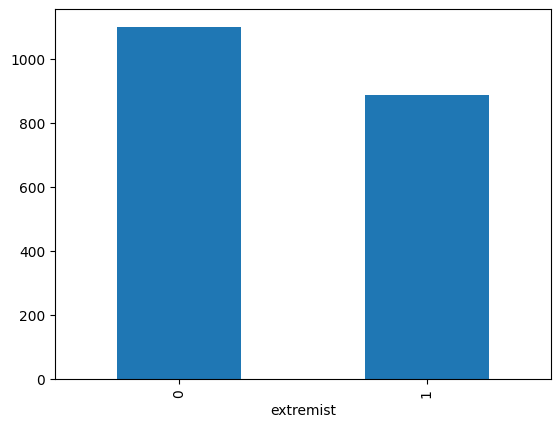

In [18]:
df["extremist"].value_counts().plot(kind="bar")
plt.show()

In [9]:
df.describe()

,extremist
count,1989.000000
mean,0.446456
std,0.497250
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [13]:
df["extremist"].describe()

count    1989.000000
mean        0.446456
std         0.497250
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: extremist, dtype: float64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   comments   1989 non-null   object
 1   extremist  1989 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 31.2+ KB


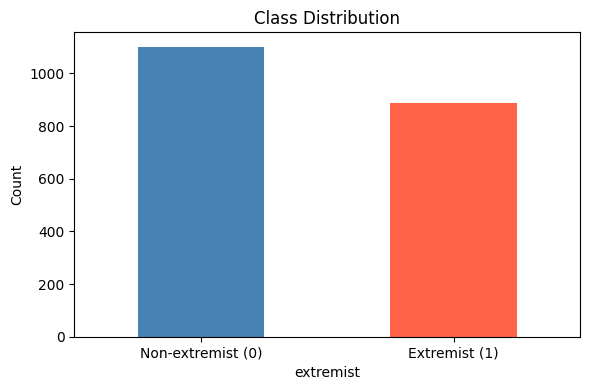

In [23]:
# Plot class distribution
fig, ax = plt.subplots(figsize=(6, 4))
df["extremist"].value_counts().plot(kind="bar", color=["steelblue", "tomato"], ax=ax)
ax.set_xticklabels(["Non-extremist (0)", "Extremist (1)"], rotation=0)
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [15]:
# Comment length distribution
df["comment_length"] = df["comments"].astype(str).apply(len)
df["word_count"]     = df["comments"].astype(str).apply(lambda x: len(x.split()))

print(df[["comment_length", "word_count"]].describe().round(1))

       comment_length  word_count
count          1989.0      1989.0
mean             51.8         8.9
std              26.9         4.5
min               5.0         1.0
25%              32.0         6.0
50%              46.0         8.0
75%              66.0        11.0
max             236.0        41.0


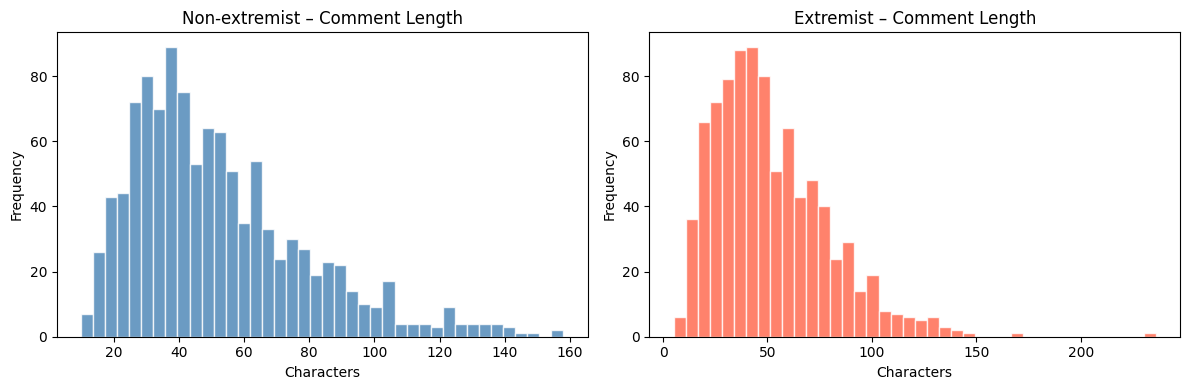

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, color, ax, col in zip(
    ["Non-extremist", "Extremist"],
    ["steelblue", "tomato"],
    axes,
    [0, 1]
):
    data = df[df["extremist"] == col]["comment_length"]
    ax.hist(data, bins=40, color=color, edgecolor="white", alpha=0.8)
    ax.set_title(f"{label} – Comment Length")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [16]:
df.head()

,comments,extremist,comment_length,word_count
0,"সমাবেশ করতে দেওয়াই উচিত না, গ্রেনেড মারা দলকে",1,45,8
1,"সমাবেশ নয়াপল্টনেই হবে,,পুলিশ বাধা দিলে পুলিশকে...",1,68,11
2,"আমি আমার ভোট দিব, এ অধিকার ফিরে পেতে চাই",0,41,9
3,মুক্তিকামী মানুষের জয় হবে ইনশাআল্লাহ,0,36,5
4,রাজনীতি এবং রাজনীতিবিদ বর্তমানে দেশের মানুষের ...,1,58,8


In [17]:
# Bengali stop-words (NLTK)
bengali_stop_words = set(stopwords.words("bengali"))

In [18]:
def preprocess_bangla(text: str) -> str:
    """Clean a single Bangla comment."""
    text = str(text)
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Keep only Bengali Unicode block (\u0980-\u09FF) + spaces
    text = re.sub(r"[^\u0980-\u09FF\s]", " ", text)
    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # Remove stop-words
    tokens = text.split()
    tokens = [t for t in tokens if t not in bengali_stop_words]
    return " ".join(tokens)

In [19]:
df["clean_comments"] = df["comments"].apply(preprocess_bangla)
print("Sample cleaned comments:")
df[["comments", "clean_comments"]].head()

Sample cleaned comments:


,comments,clean_comments
0,"সমাবেশ করতে দেওয়াই উচিত না, গ্রেনেড মারা দলকে",সমাবেশ দেওয়াই গ্রেনেড মারা দলকে
1,"সমাবেশ নয়াপল্টনেই হবে,,পুলিশ বাধা দিলে পুলিশকে...",সমাবেশ নয়াপল্টনেই পুলিশ বাধা দিলে পুলিশকে ছাড়
2,"আমি আমার ভোট দিব, এ অধিকার ফিরে পেতে চাই",ভোট দিব অধিকার পেতে চাই
3,মুক্তিকামী মানুষের জয় হবে ইনশাআল্লাহ,মুক্তিকামী মানুষের জয় ইনশাআল্লাহ
4,রাজনীতি এবং রাজনীতিবিদ বর্তমানে দেশের মানুষের ...,রাজনীতি রাজনীতিবিদ বর্তমানে দেশের মানুষের অভিশাপ


In [20]:
df[["comments", "clean_comments"]].tail()

,comments,clean_comments
1984,গমরুল সাহেব খালেদা জিয়াকে এতভয়।,গমরুল সাহেব খালেদা জিয়াকে এতভয়
1985,পাওয়ার সব সময় থাকেনা কাকু,পাওয়ার সময় থাকেনা কাকু
1986,টাকলু কই কি হাত ভেঙে হাতে ধরায়ে দিবে,টাকলু কই হাত ভেঙে হাতে ধরায়ে দিবে
1987,আমাদের দেশের রাজনীতিতে একজন সাদা মনের মানুষ। আ...,দেশের রাজনীতিতে একজন সাদা মনের মানুষ শ্রদ্ধা ভ...
1988,সাদা মন কোথায় দেখলেন?একটু দেখিয়ে দিন যাতে আমরা...,সাদা মন কোথায় দেখলেন একটু দেখিয়ে আমরাও শরিক


In [33]:
from bnltk.tokenize import Tokenizers

ModuleNotFoundError: No module named 'bnltk'

In [34]:
import urllib.request, os

In [35]:
font_path = "bangla-extremist/HindSiliguri-Regular.ttf"

In [21]:
df.head()

,comments,extremist,comment_length,word_count,clean_comments
0,"সমাবেশ করতে দেওয়াই উচিত না, গ্রেনেড মারা দলকে",1,45,8,সমাবেশ দেওয়াই গ্রেনেড মারা দলকে
1,"সমাবেশ নয়াপল্টনেই হবে,,পুলিশ বাধা দিলে পুলিশকে...",1,68,11,সমাবেশ নয়াপল্টনেই পুলিশ বাধা দিলে পুলিশকে ছাড়
2,"আমি আমার ভোট দিব, এ অধিকার ফিরে পেতে চাই",0,41,9,ভোট দিব অধিকার পেতে চাই
3,মুক্তিকামী মানুষের জয় হবে ইনশাআল্লাহ,0,36,5,মুক্তিকামী মানুষের জয় ইনশাআল্লাহ
4,রাজনীতি এবং রাজনীতিবিদ বর্তমানে দেশের মানুষের ...,1,58,8,রাজনীতি রাজনীতিবিদ বর্তমানে দেশের মানুষের অভিশাপ


In [22]:
def generate_wordcloud(texts: list, title: str = ""):
    combined = " ".join(str(t) for t in texts)
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        stopwords=bengali_stop_words,
        font_path=font_path,   # Bengali-capable font
        min_font_size=10,
    ).generate(combined if combined.strip() else "কোনো শব্দ নেই")

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.show()

non_extremist_comments = list(df[df["extremist"] == 0]["clean_comments"])
extremist_comments     = list(df[df["extremist"] == 1]["clean_comments"])

In [42]:
generate_wordcloud(non_extremist_comments, "Non-Extremist Comments")
generate_wordcloud(extremist_comments,"Extremist Comments")

OSError: cannot open resource

In [23]:
non_extremist_comments = list(df[df["extremist"] == 0]["clean_comments"])
extremist_comments     = list(df[df["extremist"] == 1]["clean_comments"])

In [24]:
non_extremist_comments

['ভোট দিব অধিকার পেতে চাই',
 'মুক্তিকামী মানুষের জয় ইনশাআল্লাহ',
 'ধন্যবাদ আসিফ নজরুল স্যারকে গণমানুষের মনের কথা ধরার',
 'দেশের মানুষের মনের কথা ধরার স্যারকে সালাম জানাই',
 'জনগণ নিরপেক্ষ সরকার চাই',
 'গনতান্ত্রিক রাষ্ট্রে পদত্যাগের দাবী অপরাধ',
 'বলবো মুখে ভাষা হারিয়ে ফেলেছি',
 'রাস্তা বন্ধ থাকলেতো জনগণের কষ্ট',
 'জনগণ কারন জনগন সচেতন পছন্দ মত ভোট চাই',
 'আল্লাহ বাংলাদেশের মানুষকে শান্তি দাও',
 'সবাই ভাল দোয়া রহিল',
 'কর্মি দেখবেন ১০ ডিসেম্বর নয়াপল্টনে',
 'সকল ভাইদের দোয়া রইল',
 'একেবারে সত্য কথা ফুটিয়ে তুলেছেন অসংখ্য ধন্যবাদ আপনাকে',
 'শান্তি পেলাম',
 'দলের ছাত্র সংগঠনই নিয়ন্ত্রণ',
 'যোগ্যতা অবস্থায়',
 'বাস্তব মুখি কথা শুনলাম',
 'নির্দলীয় সরকারের অধীনে নির্বাচনের ডাক',
 'শিক্ষিত মানুষ হওয়া যায় মানুষ মনুষত্বের প্রয়োজন',
 'বুঝতেই পারছিনা আসলে বলবো অসহায়',
 'মানুষের জীবনের নিরাপত্তা নিরাপদ ক্যাম্পাস চাই',
 'শহীদ প্রেসিডেন্ট জিয়াউর রহমান স্বাধীনতার ঘোষণা',
 'বাংলাদেশের রাজনৈতিক নেতাদের চরিত্র উন্নত হওয়া দরকার',
 'এসব ভুয়া কথা জনগণ বিশ্বাস',
 'দেশের উন্নতি দরকার',
 'মানুষ বাঁচতে চায়',

In [25]:
def generate_wordcloud2(non_extremist_comments, title=""):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=bengali_stop_words,
        min_font_size=10,
        font_path=None  
    ).generate(non_extremist_comments)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=20)
    plt.show()

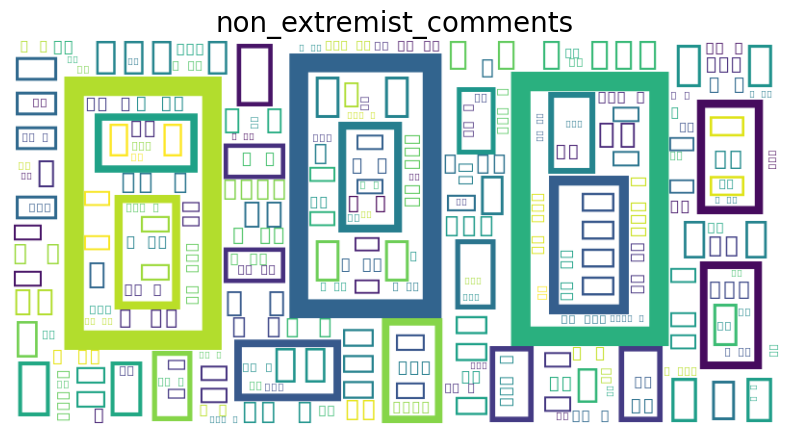

In [26]:
generate_wordcloud2(" ".join(non_extremist_comments), "non_extremist_comments")

In [27]:
extremist_comments

['সমাবেশ দেওয়াই গ্রেনেড মারা দলকে',
 'সমাবেশ নয়াপল্টনেই পুলিশ বাধা দিলে পুলিশকে ছাড়',
 'রাজনীতি রাজনীতিবিদ বর্তমানে দেশের মানুষের অভিশাপ',
 'বাংলাদেশ তামাশা লীগ',
 'বিনোদন মন্ত্রী',
 'আ লীগের জুমা কিসের',
 'অহন বোঝেন কাক্কু জয় বাংলা হয়ে',
 'চাই সরকার পতন ধ্বংস যাক',
 'কর্মী জয় বাংলা',
 'সত্যি লীগ চরম পর্যায়ের কর্মী সংকটে ভুগতেছে',
 'করোনা আসো',
 'আপনাদের দলে সবাই নেতা সবাই খাইতে',
 'কর্মী কয়দিন দূর্বিন দিয়াও খুঁজে পাওয়া',
 'কর্মীরা বুঝি ফেলছে দেশের অবস্থা ভালা',
 'নেতা আসছেন নেতার পকেটে টাকা ডুকছে',
 'এসব শর্ত বাদ নয়া পল্টনে সমাবেশ করুন সরকার পাগল',
 'কর্মী লাগে বর্তমান আওমিলীগ রাজনীতিতে বড় নেতার মন খুশি রাখতে পারলেই',
 'সরকারতো বিদায় হবেই কারন দেশটাতো জনগণের কারো বাবার জমিদারি',
 'এতো শর্ত সমাবেশ থামানো ৭১ মানেই আওয়ামী লীগ টিভি',
 'সরকার পুলিশ দিয়ে কয়দিন মাস্তানি',
 'কর্মী পেলে রোহিঙ্গাদের আসবো তাইনা কাকু',
 '৭১ চুলকানি হয়ে',
 'আওয়ামী লীগের কদিন বউ',
 'কর্মি সবাই ধান কাটতেছে',
 'কর্মী সংকটে এতো সকাল পড়েগেছেন নি ভাই দল ক্ষমতায়',
 'সবাই লাঠি',
 'এম পির অবস্হা আওয়ামীলিগেরও',
 'নেতাদে

In [28]:
def generate_wordcloud2(extremist_comments, title=""):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=bengali_stop_words,
        min_font_size=10,
        font_path=None  
    ).generate(extremist_comments)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=20)
    plt.show()

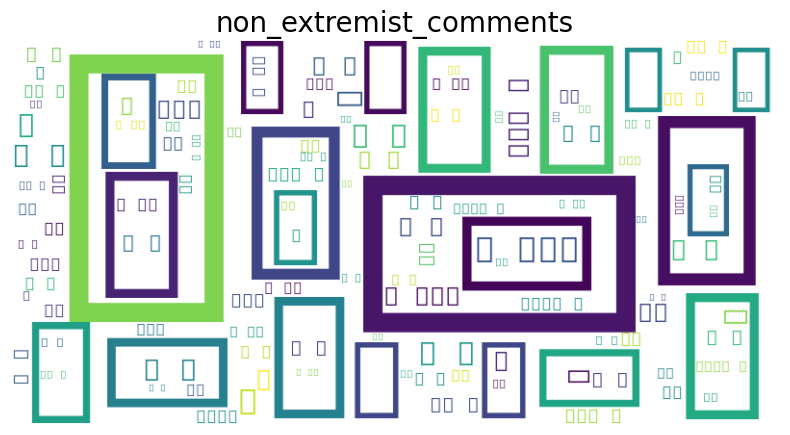

In [29]:
generate_wordcloud2(" ".join(extremist_comments), "non_extremist_comments")

## spliting x , y 

In [30]:

x = df["clean_comments"]
y = df["extremist"]


In [31]:
x.head()

0                     সমাবেশ দেওয়াই গ্রেনেড মারা দলকে
1       সমাবেশ নয়াপল্টনেই পুলিশ বাধা দিলে পুলিশকে ছাড়
2                             ভোট দিব অধিকার পেতে চাই
3                    মুক্তিকামী মানুষের জয় ইনশাআল্লাহ
4    রাজনীতি রাজনীতিবিদ বর্তমানে দেশের মানুষের অভিশাপ
Name: clean_comments, dtype: object

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [33]:
x_train.shape

(1591,)

In [34]:
print(f"Train size : {len(x_train):,}")
print(f"Test  size : {len(x_test):,}")

Train size : 1,591
Test  size : 398


In [35]:
# vector format 
count_vec = CountVectorizer(max_features=20000)
xtrain_vec= count_vec.fit_transform(x_train)
xtrain_vec

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5954 stored elements and shape (1591, 944)>

In [36]:
xtrain_vec.shape

(1591, 944)

# decission tree 

In [73]:
# model implemament
dt_clas=  DecisionTreeClassifier()
dt = dt_clas.fit(xtrain_vec, y_train)

In [74]:
dt.score(xtrain_vec, y_train)

0.9566310496543055

In [75]:
xtest_vec= count_vec.transform(x_test)
xtest_vec.shape

(398, 944)

In [76]:
dt.score(xtest_vec, y_test)

0.5804020100502513

In [79]:
df.head()

,comments,extremist,comment_length,word_count,clean_comments
0,"সমাবেশ করতে দেওয়াই উচিত না, গ্রেনেড মারা দলকে",1,45,8,সমাবেশ দেওয়াই গ্রেনেড মারা দলকে
1,"সমাবেশ নয়াপল্টনেই হবে,,পুলিশ বাধা দিলে পুলিশকে...",1,68,11,সমাবেশ নয়াপল্টনেই পুলিশ বাধা দিলে পুলিশকে ছাড়
2,"আমি আমার ভোট দিব, এ অধিকার ফিরে পেতে চাই",0,41,9,ভোট দিব অধিকার পেতে চাই
3,মুক্তিকামী মানুষের জয় হবে ইনশাআল্লাহ,0,36,5,মুক্তিকামী মানুষের জয় ইনশাআল্লাহ
4,রাজনীতি এবং রাজনীতিবিদ বর্তমানে দেশের মানুষের ...,1,58,8,রাজনীতি রাজনীতিবিদ বর্তমানে দেশের মানুষের অভিশাপ


In [80]:
data = df[0:1]["comments"]

In [82]:
data

0    সমাবেশ করতে দেওয়াই উচিত না, গ্রেনেড মারা দলকে
Name: comments, dtype: object

In [ ]:
clean_data = preprocess_bangla(data)

In [85]:
clean_data= ['রাগ করলা!']

In [86]:
data = pd.DataFrame(clean_data, columns=["comments"])
data

,comments
0,রাগ করলা!


In [88]:
# vector convert
vec_data = count_vec.transform(data["comments"])

In [89]:
vec_data.shape

(1, 944)

In [90]:
dt.predict(vec_data)

array([0])

In [95]:
prediction = dt.predict(vec_data)[0]
labels = {0: "non_extremist_comments", 1: "extremist_comments"}
result = labels[prediction]
print(f"Prediction result: {result}")

Prediction result: non_extremist_comments


In [91]:
# model save
pickle.dump(dt, open("dt_model.pkl","wb"))

In [92]:
# vector model save
pickle.dump(count_vec, open("vec_model.pkl","wb"))

## naive bayes

In [38]:
# Initialize Naive Bayes
nb_model = MultinomialNB()



In [41]:
nb = nb_model.fit(xtrain_vec, y_train)

In [42]:
nb.score(xtrain_vec, y_train)


0.7900691389063482

In [44]:
xtest_vec= count_vec.transform(x_test)
xtest_vec.shape

(398, 944)

In [45]:
nb.score(xtest_vec, y_test)

0.6809045226130653

In [47]:

data = df[0:1]["comments"]

In [ ]:
clean_data= ['রাগ করলা!']